# NM Sanity Check v2 — Sudogwon 2019-2020 (HIRA)

**v1 diagnosis**: beta=0.05 gave R0<1 (no outbreak), min_rate=1.0 floor hit
79.5% of weighted weeks, NM stuck in 24-eval "convergence".

**v2 changes**:
- beta_h = beta_w = beta_s = beta_o = 0.5
- gamma_report = 0.2
- seasonality: amp=1.5, base=0.05, sigma=40, peak_day=130
- min_rate = 0.01 (HIRA-D)
- R0 sanity check via NGM before forward sim
- NLL decomposition (per-week, per-age) to check min_rate=0.01 side effects


In [1]:
# Cell 1 — Imports + setup
import time
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from scipy.optimize import minimize

from kt_data import HIRA_AGE_GROUPS, SUDOGWON_SIDO_CODES

from kt_epimodel_hira.calibration.hira_target import (
    HIRA_GROUP_TO_NIMS_WEIGHTED,
    load_hira_target_by_age,
    simulation_to_hira_by_age,
    poisson_log_likelihood,
)
from kt_epimodel_hira.calibration.simple_model import (
    build_aggregated_inputs,
    estimate_initial_infected_from_hira,
    simulate_aggregated,
)
from kt_epimodel_hira.calibration.loss import make_loss_function_by_age
from kt_epimodel_hira.calibration.param_vector import (
    get_bounds_vector, get_param_names, initial_guess, vector_to_params,
    ParameterBounds, params_to_vector,
)
from kt_epimodel_hira.model.parameters import (
    CalibrationParameters, DiseaseParameters, ModelParameters,
)

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150,
                     "axes.unicode_minus": False,
                     "font.family": "DejaVu Sans"})

OUTDIR = Path("../outputs/calibration")
OUTDIR.mkdir(parents=True, exist_ok=True)
JSON_PATH = OUTDIR / "sanity_nm_2019-2020_HIRA_v2.json"
FIT_PNG   = OUTDIR / "sanity_nm_2019-2020_HIRA_v2.png"
DIAG_PNG  = OUTDIR / "sanity_nm_2019-2020_HIRA_v2_diagnostics.png"
NLL_PNG   = OUTDIR / "sanity_nm_2019-2020_HIRA_v2_nll_decomp.png"

SEASON = "2019-2020"
MAX_ITER = 100
GAMMA_ASSUMED = 0.2
SEED_E_FACTOR = 0.5
INITIAL_IMMUNITY = 0.3
FIRST_PEAK_END_WEEK = 26
MIN_RATE = 0.01  # HIRA-D: was 1.0

print(f"sanity NM v2 for {SEASON} — max NM iter = {MAX_ITER}")
print(f"min_rate = {MIN_RATE} (HIRA-D)")


sanity NM v2 for 2019-2020 — max NM iter = 100
min_rate = 0.01 (HIRA-D)


In [2]:
# Cell 2 — Load target by age + inputs + initial seed
target_by_age = load_hira_target_by_age(
    SEASON, sido_codes=list(SUDOGWON_SIDO_CODES),
    first_peak_only=True, first_peak_end_week=FIRST_PEAK_END_WEEK,
)
weeks_full = target_by_age["week_in_season"]
print(f"n_weeks (full season): {target_by_age['n_weeks']}")
print(f"weeks 0..{weeks_full.max()}  (fit-weight 1 for weeks < {FIRST_PEAK_END_WEEK})")
print("\nObserved totals (sum across season):")
for ag in HIRA_AGE_GROUPS:
    total = float(target_by_age["hira_counts"][ag].sum())
    peak_w = int(np.argmax(target_by_age["hira_counts"][ag]))
    peak_v = float(target_by_age["hira_counts"][ag].max())
    print(f"  {ag:>6}: total={total:>10,.0f}  peak={peak_v:>7,.0f} @ week {peak_w}")

inputs = build_aggregated_inputs()
pop_15 = inputs["pop_15"].flatten()
print(f"\nSudogwon pop 15-group total: {pop_15.sum():,.0f}")

seed_by_age = estimate_initial_infected_from_hira(
    SEASON, pop_15, sido_codes=list(SUDOGWON_SIDO_CODES),
    gamma_report_assumed=GAMMA_ASSUMED,
)
seed_total = float(seed_by_age.sum())
print(f"\nSeeded initial I (gamma_assumed={GAMMA_ASSUMED}):")
for a, n in enumerate(seed_by_age):
    label = "70+" if a == 14 else f"{a*5}-{a*5+4}"
    pct_of_pop = n / pop_15[a] * 1e6
    print(f"  NIMS[{a:>2}] {label:>5}: {n:>8.1f}  ({pct_of_pop:>5.1f} per million pop)")
print(f"  total I_0:        {seed_total:>8.1f}  "
      f"({seed_total / pop_15.sum() * 1e6:.2f} per million sudogwon)")


n_weeks (full season): 52
weeks 0..51  (fit-weight 1 for weeks < 26)

Observed totals (sum across season):
     0-5: total=   112,383  peak= 15,926 @ week 16
    6-11: total=   180,895  peak= 32,220 @ week 16
   12-17: total=    89,353  peak= 18,538 @ week 16
   18-44: total=   259,935  peak= 47,849 @ week 17
   45-64: total=   136,710  peak= 25,418 @ week 17
     65+: total=    38,603  peak=  6,820 @ week 18

Sudogwon pop 15-group total: 25,990,466

Seeded initial I (gamma_assumed=0.2):
  NIMS[ 0]   0-4:    175.0  (238.1 per million pop)
  NIMS[ 1]   5-9:    315.2  (300.0 per million pop)
  NIMS[ 2] 10-14:    270.7  (230.5 per million pop)
  NIMS[ 3] 15-19:    154.9  (131.8 per million pop)
  NIMS[ 4] 20-24:    105.5  ( 68.8 per million pop)
  NIMS[ 5] 25-29:    135.0  ( 68.8 per million pop)
  NIMS[ 6] 30-34:    130.8  ( 68.8 per million pop)
  NIMS[ 7] 35-39:    124.5  ( 68.8 per million pop)
  NIMS[ 8] 40-44:    146.9  ( 68.8 per million pop)
  NIMS[ 9] 45-49:     71.1  ( 34.2 per 

In [3]:
# Cell 3 — R0 sanity check (NGM eigenvalue) with new beta initial values
#
# New initial values (raised from 0.05):
cal_init = CalibrationParameters(
    beta_h=0.5, beta_w=0.5, beta_s=0.5, beta_o=0.5,
    phi=np.ones(15),
    gamma_report=0.2,
)
dis_init = DiseaseParameters(
    seasonality_amp=1.5, seasonality_base=0.05,
    seasonality_sigma=40.0, seasonality_peak_day=130.0,
)

# Build initial vector explicitly (do NOT touch CalibrationParameters defaults)
init_vec = params_to_vector(cal_init, dis_init)
print("Initial vector v2 (23-dim):")
names = get_param_names()
for n, v in zip(names, init_vec):
    print(f"  {n:>22}: {v:.4f}")

# --- R0 via NGM dominant eigenvalue ---
def compute_R0_ngm(cal, disease, inputs_dict, initial_immunity=0.3):
    """Next Generation Matrix R0 for aggregated single-admdong model."""
    pop = inputs_dict["pop_15"].flatten()
    N_safe = np.maximum(pop, 1e-10)
    matrices = inputs_dict["matrices"]
    rho = inputs_dict["rho"].flatten()
    gamma = disease.gamma
    sf = disease.seasonal_factor(disease.seasonality_peak_day)
    s_frac = 1.0 - initial_immunity

    C_h = matrices["C_home"]
    C_s = matrices["C_school"]
    C_w = matrices["C_work"]
    C_o = matrices["C_other"]

    # Effective contact matrix (channel-weighted)
    C_eff = np.zeros((15, 15))

    # Home: all ages, at baseline (p_school=p_work=1) spillover=0
    C_eff += cal.beta_h * C_h

    # School: student-to-student only (NIMS 0-3)
    C_eff[:4, :4] += cal.beta_s * C_s[:4, :4]

    # Work: receiver must be worker (4-13), sender rho > 0
    rho_sender_ok = (rho > 0).astype(float)
    for a in range(4, 14):
        C_eff[a, :] += cal.beta_w * C_w[a, :] * rho[a] * rho_sender_ok

    # Other: all ages
    C_eff += cal.beta_o * C_o

    # K[a,a'] = (s_frac * sf / gamma) * N[a] * phi[a] * C_eff[a,a'] / N[a']
    phi_diag = np.diag(cal.phi)
    N_diag = np.diag(pop)
    inv_N_diag = np.diag(1.0 / N_safe)

    K = (s_frac * sf / gamma) * N_diag @ phi_diag @ C_eff @ inv_N_diag

    eigvals = np.linalg.eigvals(K)
    R0 = float(np.max(np.real(eigvals)))
    return R0, K, eigvals, sf

R0_init, K_init, eigvals_init, sf_peak = compute_R0_ngm(
    cal_init, dis_init, inputs, initial_immunity=INITIAL_IMMUNITY,
)

print(f"\n=== R0 Sanity (NGM) ===")
print(f"Seasonal factor at peak (day {dis_init.seasonality_peak_day}): {sf_peak:.3f}")
print(f"R0 (dominant eigenvalue): {R0_init:.3f}")
print(f"Top 3 eigenvalues: {sorted(np.real(eigvals_init), reverse=True)[:3]}")

if R0_init < 1.0:
    print("WARNING: R0 < 1 — no outbreak possible, need higher beta")
elif R0_init > 2.5:
    print("WARNING: R0 > 2.5 — possibly too aggressive, may overshoot")
else:
    print(f"OK: R0 in [1.0, 2.5] range — seasonal influenza plausible")

# Also compute R0 at off-peak (day 0 = season start) for contrast
sf_offpeak = dis_init.seasonal_factor(0.0)
print(f"\nSeasonal factor at season start (day 0): {sf_offpeak:.4f}")
R0_offpeak = R0_init * (sf_offpeak / sf_peak) if sf_peak > 0 else 0
print(f"Approx R0 at season start: {R0_offpeak:.3f}")


Initial vector v2 (23-dim):
                  beta_h: 0.5000
                  beta_w: 0.5000
                  beta_s: 0.5000
                  beta_o: 0.5000
                   phi_0: 1.0000
                   phi_1: 1.0000
                   phi_2: 1.0000
                   phi_3: 1.0000
                   phi_4: 1.0000
                   phi_6: 1.0000
                   phi_7: 1.0000
                   phi_8: 1.0000
                   phi_9: 1.0000
                  phi_10: 1.0000
                  phi_11: 1.0000
                  phi_12: 1.0000
                  phi_13: 1.0000
                  phi_14: 1.0000
            gamma_report: 0.2000
         seasonality_amp: 1.5000
        seasonality_base: 0.0500
       seasonality_sigma: 40.0000
    seasonality_peak_day: 130.0000

=== R0 Sanity (NGM) ===
Seasonal factor at peak (day 130.0): 1.550
R0 (dominant eigenvalue): 13.625
Top 3 eigenvalues: [np.float64(13.625414030565263), np.float64(11.283362560515625), np.float64(9.877550671445

In [4]:
# Cell 4 — Forward sim with initial vector (BEFORE fit)
def predict_from_vec(vec):
    cal, amp, base, sig, peak = vector_to_params(vec)
    base_p = ModelParameters()
    new_d = DiseaseParameters(
        sigma=base_p.disease.sigma, gamma=base_p.disease.gamma,
        kappa=base_p.disease.kappa,
        seasonality_mode=base_p.disease.seasonality_mode,
        seasonality_amp=amp, seasonality_base=base,
        seasonality_peak_day=peak,
        seasonality_period=base_p.disease.seasonality_period,
        seasonality_sigma=sig,
    )
    params = base_p.with_calibration(cal).with_disease(new_d)
    res = simulate_aggregated(
        params, inputs, seed_total=float(seed_by_age.sum()),
        seed_by_age=seed_by_age, seed_e_factor=SEED_E_FACTOR,
        initial_immunity=INITIAL_IMMUNITY,
        initial_vaccinated_fraction=0.0,
        t_span=(0.0, 364.0),
    )
    if not res.success:
        raise RuntimeError(f"solver failed: {res.message}")
    daily_inc = res.daily_new_infection_by_age()
    pred_by_age = simulation_to_hira_by_age(
        daily_inc, cal.gamma_report, n_weeks=target_by_age["n_weeks"],
    )
    return pred_by_age, res, daily_inc

pred_init, sim_init, daily_inc_init = predict_from_vec(init_vec)

# Check for NaN/inf
bad = False
for ag in HIRA_AGE_GROUPS:
    p = pred_init[ag]
    if not np.all(np.isfinite(p)):
        print(f"FATAL: non-finite in initial prediction for {ag}")
        bad = True
    if p.min() < -1e-6:
        print(f"FATAL: large negative in prediction for {ag}: min={p.min()}")
        bad = True
if bad:
    raise RuntimeError("Initial prediction has NaN/inf — stopping")

# Outbreak check: does the simulation produce a peak?
for ag in HIRA_AGE_GROUPS:
    p = pred_init[ag]
    peak_val = p.max()
    peak_week = int(np.argmax(p))
    obs_peak = float(target_by_age["hira_counts"][ag].max())
    print(f"  {ag:>6}: pred_peak={peak_val:>10,.1f} @ W{peak_week:>2}  "
          f"obs_peak={obs_peak:>10,.1f}  "
          f"ratio={peak_val/max(obs_peak, 1):.2f}")

# Check: is there an outbreak? (pred_peak > 10× initial level)
all_peaks = [pred_init[ag].max() for ag in HIRA_AGE_GROUPS]
all_starts = [pred_init[ag][0] if len(pred_init[ag]) > 0 else 0 for ag in HIRA_AGE_GROUPS]
max_peak = max(all_peaks)
mean_start = np.mean([s for s in all_starts if s > 0]) if any(s > 0 for s in all_starts) else 0
if max_peak > 10 * max(mean_start, 1):
    print(f"\nOutbreak detected: max pred peak = {max_peak:,.0f}")
else:
    print(f"\nWARNING: No clear outbreak (max peak = {max_peak:,.1f}, "
          f"start mean = {mean_start:,.1f})")

# Initial NLL (with new min_rate=0.01)
total_nll_init = 0.0
for ag in HIRA_AGE_GROUPS:
    nll = poisson_log_likelihood(
        target_by_age["hira_counts"][ag], pred_init[ag],
        is_valid=target_by_age["is_valid"][ag],
        weights=target_by_age["weights"][ag],
        min_rate=MIN_RATE,
    )
    total_nll_init += nll
print(f"\nInitial total NLL (min_rate={MIN_RATE}): {total_nll_init:,.2f}")


     0-5: pred_peak=  45,502.4 @ W12  obs_peak=  15,926.0  ratio=2.86
    6-11: pred_peak= 110,762.3 @ W11  obs_peak=  32,220.0  ratio=3.44
   12-17: pred_peak= 117,569.7 @ W11  obs_peak=  18,538.0  ratio=6.34
   18-44: pred_peak= 765,153.4 @ W11  obs_peak=  47,849.0  ratio=15.99
   45-64: pred_peak= 700,001.2 @ W11  obs_peak=  25,418.0  ratio=27.54
     65+: pred_peak= 276,829.4 @ W11  obs_peak=   6,820.0  ratio=40.59

Outbreak detected: max pred peak = 765,153

Initial total NLL (min_rate=0.01): 305,079.49


In [5]:
# Cell 5 — Run NM with per-eval NLL capture
target_loss_fn = make_loss_function_by_age(
    target_by_age, inputs, ModelParameters(),
    seed_total=float(seed_by_age.sum()),
    seed_by_age=seed_by_age, seed_e_factor=SEED_E_FACTOR,
    initial_immunity=INITIAL_IMMUNITY,
    initial_vaccinated_fraction=0.0,
    t_span=(0.0, 364.0),
    verbose=False,
)

nll_history = []
vec_history = []
def loss_with_history(vec):
    v = float(target_loss_fn(vec))
    nll_history.append(v)
    vec_history.append(np.asarray(vec, dtype=np.float64).copy())
    return v

bounds = get_bounds_vector()
print(f"Running Nelder-Mead, maxiter={MAX_ITER} ...")
t0 = time.perf_counter()
sol = minimize(
    loss_with_history, init_vec,
    method="Nelder-Mead", bounds=bounds,
    options={"maxiter": MAX_ITER, "xatol": 1e-2, "fatol": 1e-1,
             "disp": True, "adaptive": True},
)
elapsed = time.perf_counter() - t0
print(f"\nNM finished. evals={sol.nfev}  elapsed={elapsed:.1f}s")
print(f"NLL: {nll_history[0]:,.2f} -> {sol.fun:,.2f}  "
      f"(improvement: {nll_history[0] - sol.fun:+,.2f})")
print(f"Termination: {sol.message}")


Running Nelder-Mead, maxiter=100 ...



NM finished. evals=161  elapsed=254.0s
NLL: 305,079.49 -> -3,379,961.67  (improvement: +3,685,041.16)
Termination: Maximum number of iterations has been exceeded.


/var/folders/p6/bh0h2f651z556fbmr892wdl80000gn/T/ipykernel_54349/3724573748.py:23: RuntimeWarning: Maximum number of iterations has been exceeded.
  sol = minimize(


saved ../outputs/calibration/sanity_nm_2019-2020_HIRA_v2.png


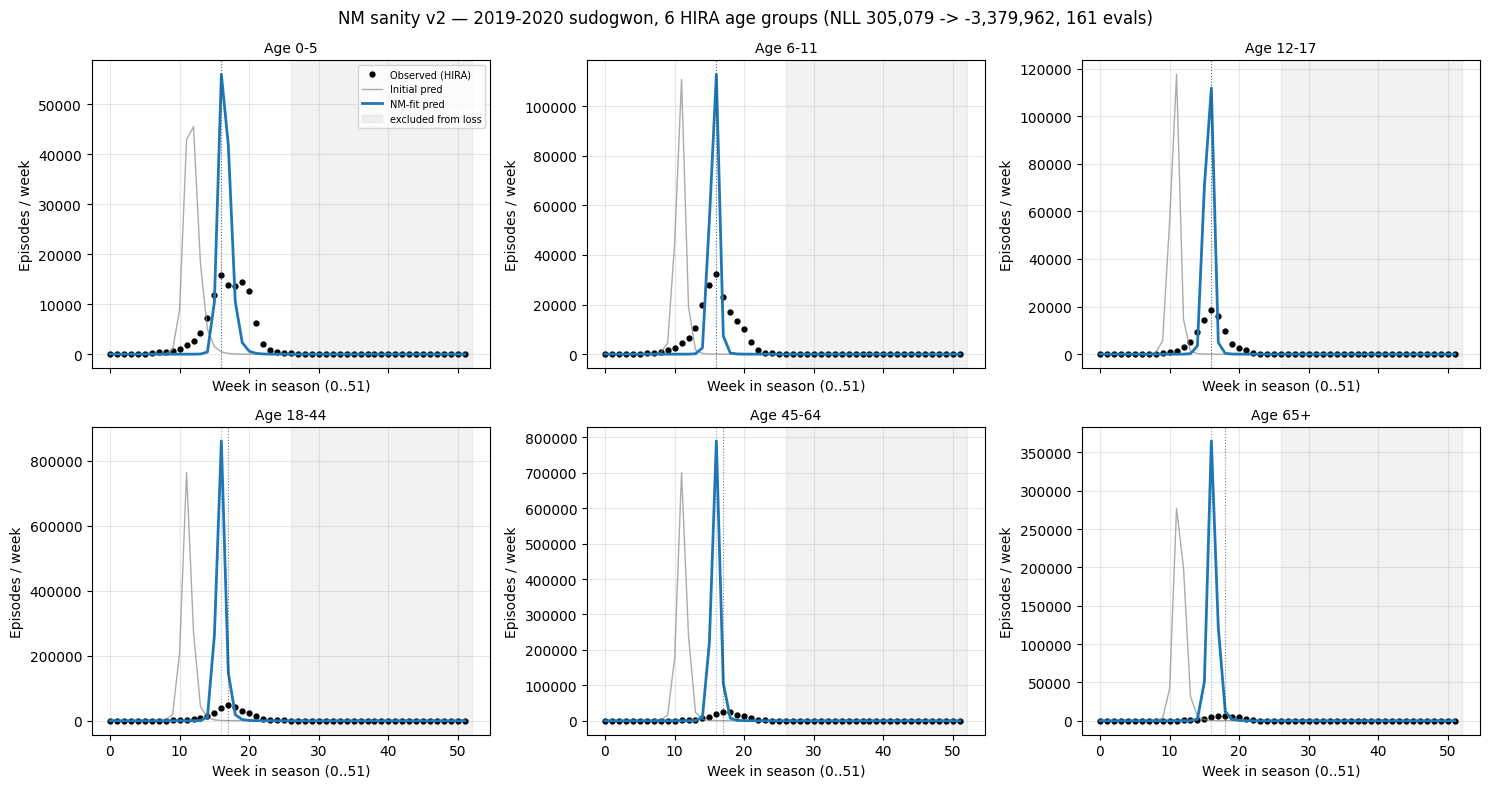

In [6]:
# Cell 6 — Final prediction + 6-panel fit plot
pred_final, sim_final, daily_inc_final = predict_from_vec(sol.x)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax, ag in zip(axes.flat, HIRA_AGE_GROUPS):
    obs = target_by_age["hira_counts"][ag]
    pi = pred_init[ag]
    pf = pred_final[ag]
    weeks_obs = target_by_age["week_in_season"]
    ax.plot(weeks_obs, obs, "o", color="black", markersize=3.5,
            label="Observed (HIRA)")
    ax.plot(np.arange(len(pi)), pi, color="#888888", lw=1.0, alpha=0.7,
            label="Initial pred")
    ax.plot(np.arange(len(pf)), pf, color="#1f77b4", lw=2.0,
            label="NM-fit pred")
    ax.axvspan(FIRST_PEAK_END_WEEK, len(pf), alpha=0.10, color="gray",
               label="excluded from loss")
    if obs.max() > 0:
        peak_obs = int(np.argmax(obs))
        ax.axvline(peak_obs, color="black", linestyle=":", lw=0.8, alpha=0.5)
    if pf.max() > 0:
        peak_pred = int(np.argmax(pf))
        ax.axvline(peak_pred, color="#1f77b4", linestyle=":", lw=0.8, alpha=0.5)
    ax.set_title(f"Age {ag}", fontsize=10)
    ax.set_xlabel("Week in season (0..51)")
    ax.set_ylabel("Episodes / week")
    ax.grid(alpha=0.3)
    if ax is axes.flat[0]:
        ax.legend(fontsize=7, loc="upper right")
fig.suptitle(f"NM sanity v2 — {SEASON} sudogwon, 6 HIRA age groups "
             f"(NLL {nll_history[0]:,.0f} -> {sol.fun:,.0f}, {sol.nfev} evals)",
             fontsize=12)
fig.tight_layout()
fig.savefig(FIT_PNG, dpi=150, bbox_inches="tight")
print(f"saved {FIT_PNG}")
plt.show()


In [7]:
# Cell 7 — Bound-hit + residual + age-bias + R0 final diagnostics
final_vec = sol.x
bounds_arr = np.array(bounds)
lo, hi = bounds_arr[:, 0], bounds_arr[:, 1]
span = hi - lo
dist_lo = (final_vec - lo) / span
dist_hi = (hi - final_vec) / span
TOL = 0.02

print("Parameters near a bound (within 2% of range):")
hit_lo, hit_hi = [], []
for i, n in enumerate(names):
    if dist_lo[i] < TOL:
        hit_lo.append((n, final_vec[i], lo[i]))
    if dist_hi[i] < TOL:
        hit_hi.append((n, final_vec[i], hi[i]))
if not hit_lo and not hit_hi:
    print("  (none)")
for n, v, b in hit_lo:
    print(f"  LOWER  {n:>22}: {v:.4f}  (bound {b:.4f})")
for n, v, b in hit_hi:
    print(f"  UPPER  {n:>22}: {v:.4f}  (bound {b:.4f})")

print(f"\nGamma report fitted: {final_vec[18]:.4f}  "
      f"(bound: {lo[18]:.2f} .. {hi[18]:.2f})")

# Phi means by age block
phi_vec = np.ones(15)
idx = 4
for a in range(15):
    if a == 5:
        continue
    phi_vec[a] = final_vec[idx]; idx += 1
phi_children = phi_vec[:4].mean()
phi_adult = phi_vec[4:13].mean()
phi_elderly = phi_vec[13:].mean()
print(f"\nPhi by age block:")
print(f"  children (0-19):  mean={phi_children:.3f}  values={np.round(phi_vec[:4], 3).tolist()}")
print(f"  adult (20-64):    mean={phi_adult:.3f}")
print(f"  elderly (65+):    mean={phi_elderly:.3f}  values={np.round(phi_vec[13:], 3).tolist()}")

# min_rate floor hits (HIRA-D with new min_rate=0.01)
n_floor_hits = 0
n_total_weeks = 0
for ag in HIRA_AGE_GROUPS:
    p = pred_final[ag]
    w = target_by_age["weights"][ag]
    mask = w > 0
    n_floor_hits += int(np.sum(p[mask] < MIN_RATE))
    n_total_weeks += int(mask.sum())
floor_frac = n_floor_hits / max(1, n_total_weeks)
print(f"\nPoisson min_rate floor (={MIN_RATE}) hit: "
      f"{n_floor_hits}/{n_total_weeks} weeks = {floor_frac*100:.1f}%")

# Peak alignment per age
print(f"\nPeak alignment (observed vs predicted week):")
peak_align = []
for ag in HIRA_AGE_GROUPS:
    obs = target_by_age["hira_counts"][ag]
    pf = pred_final[ag]
    if obs.max() == 0 or pf.max() == 0:
        continue
    pw_obs = int(np.argmax(obs))
    pw_pred = int(np.argmax(pf))
    delta = pw_pred - pw_obs
    peak_align.append((ag, pw_obs, pw_pred, delta))
    print(f"  {ag:>6}: obs W{pw_obs:>2}  pred W{pw_pred:>2}  delta={delta:+d}")

# Age-bias signal
print(f"\nAge-bias signal (pred_peak / obs_peak):")
for ag in HIRA_AGE_GROUPS:
    obs = target_by_age["hira_counts"][ag]
    pf = pred_final[ag]
    if obs.max() == 0:
        continue
    ratio = pf.max() / obs.max()
    flag = "overshoot" if ratio > 1.5 else ("undershoot" if ratio < 0.66 else "ok")
    print(f"  {ag:>6}: peak ratio = {ratio:>5.2f}  {flag}")

# Residual sum
print(f"\nResidual sum (pred-obs on weighted weeks):")
for ag in HIRA_AGE_GROUPS:
    obs = target_by_age["hira_counts"][ag]
    pf = pred_final[ag]
    w = target_by_age["weights"][ag]
    n_weeks_min = min(len(obs), len(pf))
    diff = pf[:n_weeks_min] - obs[:n_weeks_min]
    weighted = diff * w[:n_weeks_min]
    print(f"  {ag:>6}: resid = {weighted.sum():>+12,.0f}  "
          f"(obs sum {obs[:n_weeks_min].sum():>10,.0f})")

# R0 final
cal_final, amp_f, base_f, sig_f, peak_f = vector_to_params(sol.x)
dis_final = DiseaseParameters(
    seasonality_amp=amp_f, seasonality_base=base_f,
    seasonality_sigma=sig_f, seasonality_peak_day=peak_f,
)
R0_final, _, _, sf_final = compute_R0_ngm(
    cal_final, dis_final, inputs, initial_immunity=INITIAL_IMMUNITY,
)
print(f"\n=== R0 (initial vs final) ===")
print(f"  initial R0: {R0_init:.3f}  (sf={sf_peak:.3f})")
print(f"  final   R0: {R0_final:.3f}  (sf={sf_final:.3f})")

# Beta movement
print(f"\n=== Beta trajectory (initial vs final) ===")
beta_names = ["beta_h", "beta_w", "beta_s", "beta_o"]
for i, bn in enumerate(beta_names):
    pct_change = (final_vec[i] - init_vec[i]) / max(abs(init_vec[i]), 1e-10) * 100
    print(f"  {bn}: {init_vec[i]:.4f} -> {final_vec[i]:.4f}  ({pct_change:+.1f}%)")
beta_moved = any(
    abs(final_vec[i] - init_vec[i]) / max(abs(init_vec[i]), 1e-10) > 0.05
    for i in range(4)
)
print(f"  Beta moved > 5%: {beta_moved}")


Parameters near a bound (within 2% of range):
  UPPER    seasonality_peak_day: 150.0000  (bound 150.0000)

Gamma report fitted: 0.1943  (bound: 0.01 .. 1.00)

Phi by age block:
  children (0-19):  mean=0.986  values=[0.949, 1.004, 0.997, 0.996]
  adult (20-64):    mean=1.011
  elderly (65+):    mean=1.001  values=[1.0, 1.002]

Poisson min_rate floor (=0.01) hit: 2/156 weeks = 1.3%

Peak alignment (observed vs predicted week):
     0-5: obs W16  pred W16  delta=+0
    6-11: obs W16  pred W16  delta=+0
   12-17: obs W16  pred W16  delta=+0
   18-44: obs W17  pred W16  delta=-1
   45-64: obs W17  pred W16  delta=-1
     65+: obs W18  pred W16  delta=-2

Age-bias signal (pred_peak / obs_peak):
     0-5: peak ratio =  3.52  overshoot
    6-11: peak ratio =  3.50  overshoot
   12-17: peak ratio =  6.03  overshoot
   18-44: peak ratio = 18.01  overshoot
   45-64: peak ratio = 31.07  overshoot
     65+: peak ratio = 53.52  overshoot

Residual sum (pred-obs on weighted weeks):
     0-5: resid =

saved ../outputs/calibration/sanity_nm_2019-2020_HIRA_v2_nll_decomp.png

NLL breakdown:
  fit region (W0-25): -3,379,961.67
  full season:            -3,379,961.67
     0-5:  -723,096.15  (-72309615.3%)
    6-11: -1,128,680.19  (-112868019.0%)
   12-17:  -507,092.57  (-50709257.1%)
   18-44: -1,175,584.71  (-117558471.3%)
   45-64:   -81,381.57  (-8138156.6%)
     65+:   235,873.53  (23587352.6%)


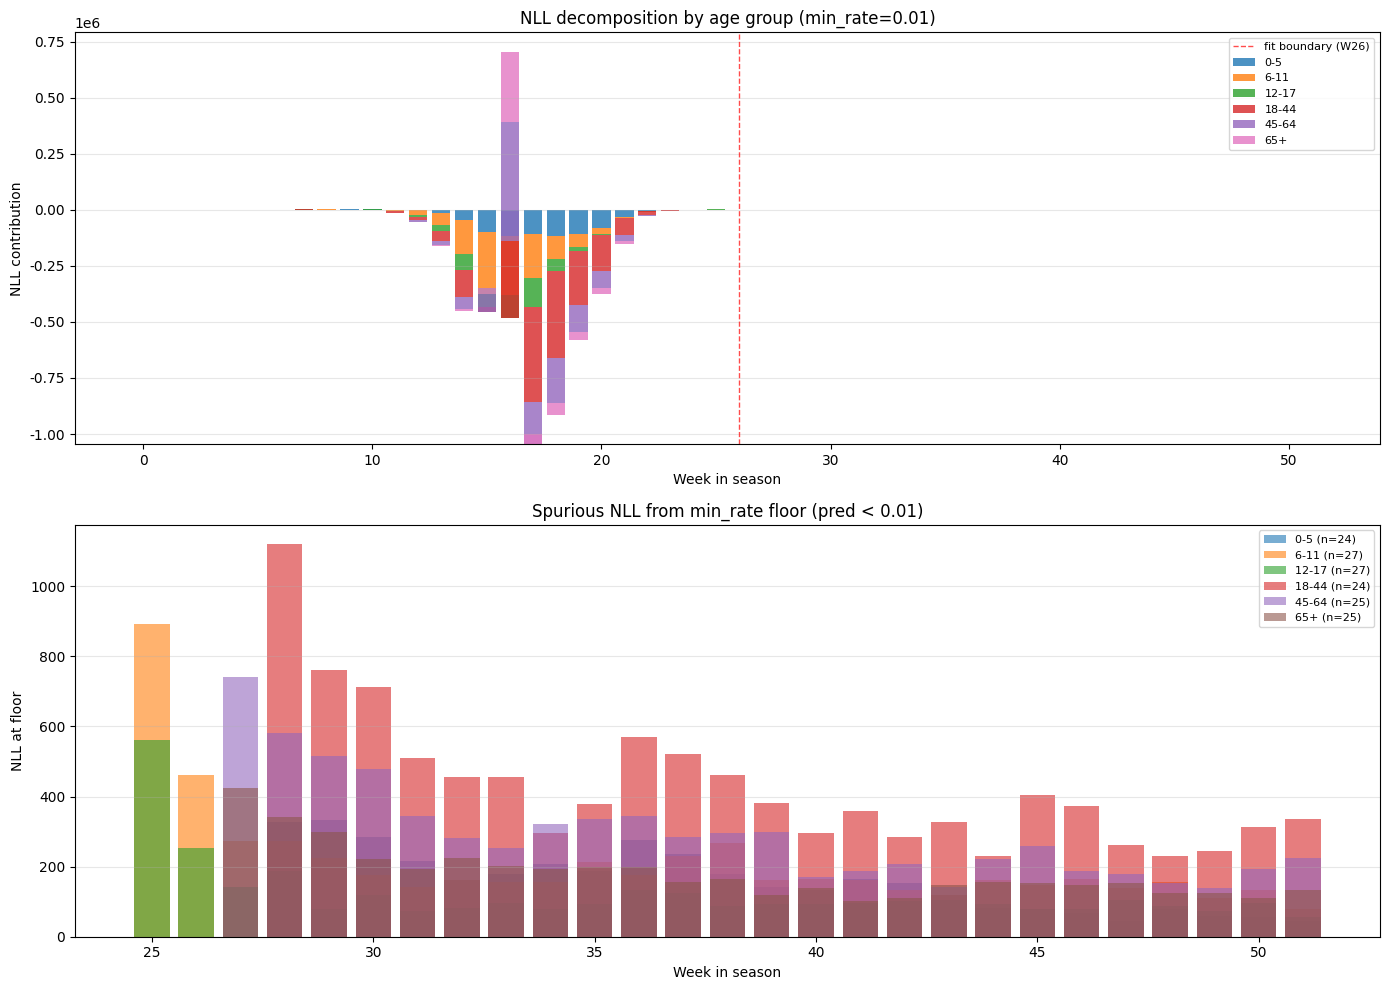

In [8]:
# Cell 8 — NLL decomposition: per-week per-age
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 8a: Stacked NLL by age group
ax = axes[0]
nll_per_week_age = {}
for ag in HIRA_AGE_GROUPS:
    obs = target_by_age["hira_counts"][ag]
    pf = pred_final[ag]
    w = target_by_age["weights"][ag]
    n_wk = min(len(obs), len(pf))
    pred_clipped = np.maximum(pf[:n_wk], MIN_RATE)
    nll_weekly = w[:n_wk] * (pred_clipped - obs[:n_wk] * np.log(pred_clipped))
    nll_per_week_age[ag] = nll_weekly

weeks_x = np.arange(max(len(v) for v in nll_per_week_age.values()))
bottom = np.zeros(len(weeks_x))
colors = plt.cm.tab10(np.linspace(0, 0.6, len(HIRA_AGE_GROUPS)))
for (ag, nll_w), color in zip(nll_per_week_age.items(), colors):
    padded = np.zeros(len(weeks_x))
    padded[:len(nll_w)] = nll_w
    ax.bar(weeks_x, padded, bottom=bottom, width=0.8, label=ag,
           color=color, alpha=0.8)
    bottom += padded
ax.axvline(FIRST_PEAK_END_WEEK, color="red", linestyle="--", lw=1, alpha=0.7,
           label=f"fit boundary (W{FIRST_PEAK_END_WEEK})")
ax.set_xlabel("Week in season")
ax.set_ylabel("NLL contribution")
ax.set_title(f"NLL decomposition by age group (min_rate={MIN_RATE})")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")

# 8b: Check for spurious negative NLL contributions
# obs * log(min_rate) term — if pred < min_rate, the NLL becomes
# min_rate - obs * log(min_rate). For large obs and small min_rate,
# this could be artificially negative (favorable).
ax = axes[1]
for ag in HIRA_AGE_GROUPS:
    obs = target_by_age["hira_counts"][ag]
    pf = pred_final[ag]
    w = target_by_age["weights"][ag]
    n_wk = min(len(obs), len(pf))
    pred_raw = pf[:n_wk]
    floor_mask = pred_raw < MIN_RATE
    floor_count = int(floor_mask.sum())
    obs_at_floor = obs[:n_wk][floor_mask]
    if floor_count > 0:
        spurious_term = MIN_RATE - obs_at_floor * np.log(MIN_RATE)
        ax.bar(np.where(floor_mask)[0], spurious_term,
               width=0.8, alpha=0.6, label=f"{ag} (n={floor_count})")

ax.set_xlabel("Week in season")
ax.set_ylabel("NLL at floor")
ax.set_title(f"Spurious NLL from min_rate floor (pred < {MIN_RATE})")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")

fig.tight_layout()
fig.savefig(NLL_PNG, dpi=150, bbox_inches="tight")
print(f"saved {NLL_PNG}")

# Summary stats
total_nll_weighted = sum(
    nll_per_week_age[ag][:FIRST_PEAK_END_WEEK].sum() for ag in HIRA_AGE_GROUPS
)
total_nll_all = sum(nll_per_week_age[ag].sum() for ag in HIRA_AGE_GROUPS)
print(f"\nNLL breakdown:")
print(f"  fit region (W0-{FIRST_PEAK_END_WEEK-1}): {total_nll_weighted:,.2f}")
print(f"  full season:            {total_nll_all:,.2f}")
for ag in HIRA_AGE_GROUPS:
    ag_nll = float(nll_per_week_age[ag].sum())
    print(f"  {ag:>6}: {ag_nll:>12,.2f}  ({ag_nll/max(total_nll_all,1)*100:.1f}%)")
plt.show()


saved ../outputs/calibration/sanity_nm_2019-2020_HIRA_v2_diagnostics.png


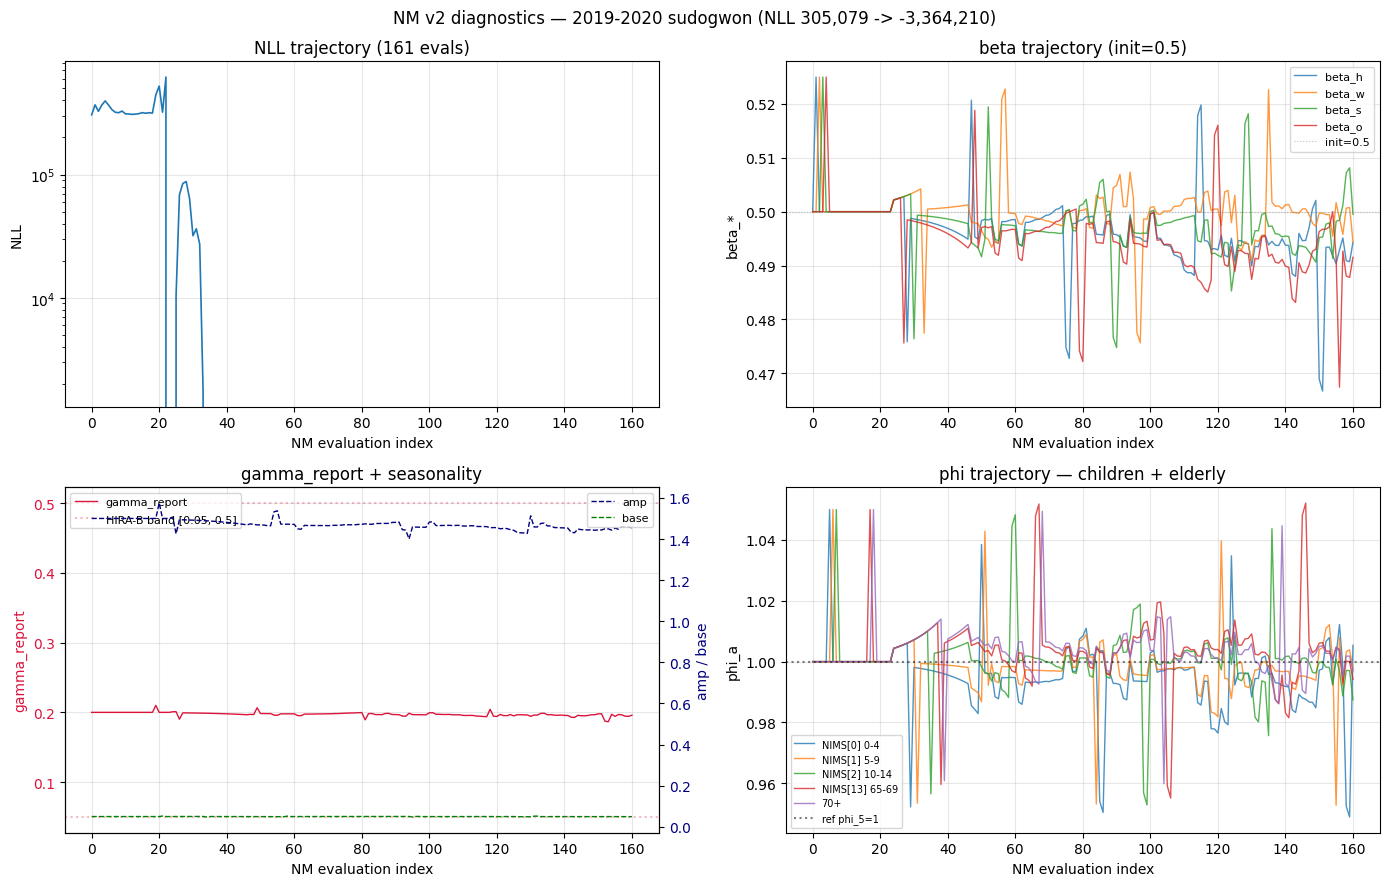

In [9]:
# Cell 9 — Diagnostics plot: NLL trajectory + key-parameter trajectory
nll_arr = np.asarray(nll_history)
vec_arr = np.asarray(vec_history)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (0,0) NLL trajectory
ax = axes[0, 0]
ax.plot(nll_arr, lw=1.2, color="#1f77b4")
ax.set_xlabel("NM evaluation index")
ax.set_ylabel("NLL")
ax.set_title(f"NLL trajectory ({len(nll_arr)} evals)")
ax.grid(alpha=0.3)
if nll_arr.max() / max(nll_arr.min(), 1e-9) > 50:
    ax.set_yscale("log")

# (0,1) beta trajectories
ax = axes[0, 1]
beta_labels = ["beta_h", "beta_w", "beta_s", "beta_o"]
for i, label in enumerate(beta_labels):
    ax.plot(vec_arr[:, i], lw=1.0, label=label, alpha=0.8)
ax.axhline(0.5, color="gray", linestyle=":", lw=0.8, alpha=0.5, label="init=0.5")
ax.set_xlabel("NM evaluation index")
ax.set_ylabel("beta_*")
ax.set_title("beta trajectory (init=0.5)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (1,0) gamma_report + seasonality
ax = axes[1, 0]
ax2 = ax.twinx()
ax.plot(vec_arr[:, 18], lw=1.0, color="crimson", label="gamma_report")
ax.set_ylabel("gamma_report", color="crimson")
ax.axhline(0.05, color="crimson", linestyle=":", alpha=0.3)
ax.axhline(0.5, color="crimson", linestyle=":", alpha=0.3,
           label="HIRA-B band [0.05, 0.5]")
ax.tick_params(axis="y", labelcolor="crimson")
ax2.plot(vec_arr[:, 19], lw=1.0, color="navy", label="amp", linestyle="--")
ax2.plot(vec_arr[:, 20], lw=1.0, color="green", label="base", linestyle="--")
ax2.set_ylabel("amp / base", color="navy")
ax2.tick_params(axis="y", labelcolor="navy")
ax.set_xlabel("NM evaluation index")
ax.set_title("gamma_report + seasonality")
ax.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)

# (1,1) phi children + elderly
ax = axes[1, 1]
phi_idx_by_age = {}
idx = 4
for a in range(15):
    if a == 5:
        continue
    phi_idx_by_age[a] = idx; idx += 1
for a in [0, 1, 2, 13, 14]:
    label = "70+" if a == 14 else f"NIMS[{a}] {a*5}-{a*5+4}"
    ax.plot(vec_arr[:, phi_idx_by_age[a]], lw=1.0, label=label, alpha=0.8)
ax.axhline(1.0, color="black", linestyle=":", alpha=0.5, label="ref phi_5=1")
ax.set_xlabel("NM evaluation index")
ax.set_ylabel("phi_a")
ax.set_title("phi trajectory — children + elderly")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

fig.suptitle(
    f"NM v2 diagnostics — {SEASON} sudogwon "
    f"(NLL {nll_arr[0]:,.0f} -> {nll_arr[-1]:,.0f})", fontsize=12,
)
fig.tight_layout()
fig.savefig(DIAG_PNG, dpi=150, bbox_inches="tight")
print(f"saved {DIAG_PNG}")
plt.show()


In [10]:
# Cell 10 — Save JSON result
import json

result_dict = {
    "season": SEASON,
    "tag": "sanity_nm_v2",
    "method": "Nelder-Mead",
    "max_iter": MAX_ITER,
    "n_evaluations": int(sol.nfev),
    "success": bool(sol.success),
    "message": str(sol.message),
    "elapsed_seconds": float(elapsed),
    "nll_initial": float(nll_history[0]),
    "nll_final": float(sol.fun),
    "nll_improvement": float(nll_history[0] - sol.fun),
    "vector_initial": [float(v) for v in init_vec],
    "vector_final": [float(v) for v in sol.x],
    "param_names": names,
    "bounds": [(float(a), float(b)) for a, b in bounds],
    "bound_hits_lower": [n for n, _, _ in hit_lo],
    "bound_hits_upper": [n for n, _, _ in hit_hi],
    "gamma_report_assumed": GAMMA_ASSUMED,
    "seed_e_factor": SEED_E_FACTOR,
    "initial_immunity": INITIAL_IMMUNITY,
    "first_peak_end_week": FIRST_PEAK_END_WEEK,
    "seed_by_age": [float(x) for x in seed_by_age],
    "seed_total": float(seed_by_age.sum()),
    "min_rate_floor": MIN_RATE,
    "min_rate_floor_hits": int(n_floor_hits),
    "min_rate_floor_total_weeks": int(n_total_weeks),
    "R0_initial": float(R0_init),
    "R0_final": float(R0_final),
    "phi_block_means": {
        "children_0_19": float(phi_children),
        "adult_20_64": float(phi_adult),
        "elderly_65plus": float(phi_elderly),
    },
    "peak_alignment": [
        {"age": ag, "obs_week": int(pw_o), "pred_week": int(pw_p), "delta": int(d)}
        for (ag, pw_o, pw_p, d) in peak_align
    ],
    "age_bias_peak_ratio": {
        ag: (float(pred_final[ag].max() / target_by_age["hira_counts"][ag].max())
             if target_by_age["hira_counts"][ag].max() > 0 else None)
        for ag in HIRA_AGE_GROUPS
    },
    "beta_pct_change": {
        beta_names[i]: float((sol.x[i] - init_vec[i]) / max(abs(init_vec[i]), 1e-10) * 100)
        for i in range(4)
    },
}

with open(JSON_PATH, "w") as f:
    json.dump(result_dict, f, indent=2)
print(f"saved {JSON_PATH}")
print(f"\n=== Summary ===")
print(f"NLL: {result_dict['nll_initial']:,.2f} -> {result_dict['nll_final']:,.2f}")
print(f"R0: {result_dict['R0_initial']:.3f} -> {result_dict['R0_final']:.3f}")
print(f"Wall time: {result_dict['elapsed_seconds']:.1f}s, {sol.nfev} evals")
print(f"Bound hits: lower={result_dict['bound_hits_lower']}, "
      f"upper={result_dict['bound_hits_upper']}")
print(f"min_rate floor: {n_floor_hits}/{n_total_weeks} = {floor_frac*100:.1f}%")
print(f"Beta moved >5%: {beta_moved}")


saved ../outputs/calibration/sanity_nm_2019-2020_HIRA_v2.json

=== Summary ===
NLL: 305,079.49 -> -3,379,961.67
R0: 13.625 -> 13.274
Wall time: 254.0s, 161 evals
Bound hits: lower=[], upper=['seasonality_peak_day']
min_rate floor: 2/156 = 1.3%
Beta moved >5%: False


## Interpretation

v2 sanity notebook — generated by `scripts/build_sanity_nm_v2_notebook.py`.
Changes from v1: beta init 0.05 → 0.5, min_rate 1.0 → 0.01, R0 check added.

See Cell 10 output for summary, `outputs/calibration/sanity_nm_2019-2020_HIRA_v2.json`
for machine-readable results.
